
Task 0: Setting up Ollama (1p)
a) Set up Ollama and connect to it using either openAI's API or Ollama's own API.

b) Load the 270m parameter version of the gemma3 model and test it with any prompt.

c) Load the 4b parameter version of the gemma3 and test it with any prompt. If running the 4b version is too slow, you can use the 1b version instead.

In [54]:
!pip install openai
from openai import OpenAI
import httpx
custom_http_client = httpx.Client(verify = False )
client = OpenAI(
    base_url = 'http://localhost:11434/v1/',
    api_key = '288109C',
    http_client = custom_http_client 
)

In [55]:
#0b)
response_270m = client.chat.completions.create(
    model="gemma3:270m",
    messages =[
        {"role": "user", "content": "Explain machine learning in one simple sentence."}
    ]
)
print(response_270m.choices[0].message.content)

Machine learning is a powerful tool that helps computers learn from data without being explicitly programmed.



In [56]:
#0c)
response_4b = client.chat.completions.create(
    model = "gemma3:4b",
    messages = [
        {"role": "user", "content": "Describe Ollama in 2 sentences."}
    ]
)
print(response_4b.choices[0].message.content)

Ollama is a remarkably simple tool that lets you download, run, and experiment with large language models (LLMs) directly from your terminal, without needing to manage complex infrastructure. It’s designed to make running powerful AI models accessible to everyone, regardless of their technical expertise.


Task 1: Text classification with Ollama (2p)
The data/emails.csv file contains 12 email headlines, with 4 spam emails, 4 legitimate work emails and 4 vague emails that are hard to classify based on the title alone. Use this dataset for all subtasks in this task.

a) Make a function for classifying emails (based on the headlines) as spam, work or unknown. The function should return only the classification and nothing else. (0.5p)

b) Use the smaller gemma3 (270m) to classify the emails using the function created in part a. (0.5p)

c) Use larger gemma3 (4b) to classify the emails using the function created in part a). In separate markdown cell, write a brief comment comparing the results of parts b) and c). (0.5p)

d) Write a script that repeats b) and c) 3 times, storing the results for both models separately. For both models, put the results as columns into a new DataFrame that also contains the headlines so that it is easy to compare how the output varied across runs for both models. Comment if there were differences and explain why this happened. (0.5p)

In [57]:
#1a)
def classify_email(headline, model_name):
    #Classify an email headline as 'spam', 'work', or 'unknown'.
    prompt = f"""
    You are an email classifier.
    Classify the following email subject line into exactly one of these categories: spam, work, or unknown.
    Rules:
    - spam: unsolicited messages, scams, or ads.
    - work: professional or job-related emails.
    - unknown: ambiguous subjects.
    Respond with Only the single word lable and nothing else.
    Subject: {headline}
    """
    response = client.chat.completions.create(
        model = model_name,
        messages = [
            {"role": "user", "content": prompt}
        ],
        temperature = 0.0
    )

    result = response.choices[0].message.content  # Fixed: changed '-' to '='
    result = result.strip().lower()
    return result

test_headline = "Urgent: You've won 100 million euros - claim your prize now!"
print(f"Test result:{classify_email(test_headline,'gemma3:4b')}")


Test result:spam


In [58]:
#1b)
import pandas as pd
df_emails = pd.read_csv('data/emails.csv', sep='\t')

print("--- Original Data ---")
display(df_emails.head())

print("\nClassifying using gemma3:270m")
df_emails['label_270m'] = df_emails['headline'].apply(
    lambda x: classify_email(x, model_name = "gemma3:270m")
)
print("\n--- Classification Results (270m) ---")
display(df_emails)

--- Original Data ---


,headline
0,URGENT: Your account will be suspended within ...
1,Congratulations! You have won a 1000€ gift car...
2,Hot singles in your area are waiting to meet y...
3,Re: Inheritance transfer of 4.5M USD pending y...
4,Meeting agenda for Thursday's project review



Classifying using gemma3:270m

--- Classification Results (270m) ---


,headline,label_270m
0,URGENT: Your account will be suspended within ...,unscheduled
1,Congratulations! You have won a 1000€ gift car...,lable
2,Hot singles in your area are waiting to meet y...,unknown
3,Re: Inheritance transfer of 4.5M USD pending y...,unknown
4,Meeting agenda for Thursday's project review,unknown
5,"Q3 budget report attached, please review by Fr...",unknown
6,Reminder: Annual performance review scheduled ...,unknown
7,"Updated draft of the manuscript, comments welcome",unknown
8,Quick question about last week,unknown
9,Following up,unknown


In [59]:
print("Classifying using gemma3:4b...")
df_emails['label_4b'] = df_emails['headline'].apply(
    lambda x: classify_email(x, model_name= "gemma3:4b")
)
print("\n--Final Results (Both models)--")
display(df_emails)

Classifying using gemma3:4b...

--Final Results (Both models)--


,headline,label_270m,label_4b
0,URGENT: Your account will be suspended within ...,unscheduled,spam
1,Congratulations! You have won a 1000€ gift car...,lable,spam
2,Hot singles in your area are waiting to meet y...,unknown,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,unknown,work
4,Meeting agenda for Thursday's project review,unknown,work
5,"Q3 budget report attached, please review by Fr...",unknown,work
6,Reminder: Annual performance review scheduled ...,unknown,work
7,"Updated draft of the manuscript, comments welcome",unknown,work
8,Quick question about last week,unknown,unknown
9,Following up,unknown,work


Comparision between gemma3:270m and gemma3:4b
Based on the result, there is a significant difference in the perfromance between the two models:
*gemma3: 270m: Struggle with the task. It fails to follow the ouput constraints (returning words like "unschedule" and "label") and classifies almost everything as "unknown". This suggests this model lacks the understanding required for this classification task.
*gemma3:4b (larger model): Shows excellent performance. It correctly identifies all 4 spam emails and 4 work emails,and appropriately labels ambiguous one as "unknown".It follows the instructions perfectly, providing only the requested labels.
In conclusion: the 4b model is more reliable for text classification tasks the than 270m model.


In [60]:
#1d)
print("Starting 3 repetitions for moth models.")
df_consistency = df_emails[['headline']].copy()

for i in range (1,4):
    print(f"Run {i} in progress...")
    df_consistency[f'270m_run_{i}'] = df_consistency['headline'].apply(
        lambda x: classify_email(x, model_name = "gemma3:270m")
    )
    df_consistency[f'4b_run){i}'] = df_consistency['headline'].apply(
        lambda x: classify_email(x, model_name = "gemma3:4b")
    )
print("Consistency Comparision Table")
display(df_consistency)

Starting 3 repetitions for moth models.
Run 1 in progress...
Run 2 in progress...
Run 3 in progress...
Consistency Comparision Table


,headline,270m_run_1,4b_run)1,270m_run_2,4b_run)2,270m_run_3,4b_run)3
0,URGENT: Your account will be suspended within ...,unscheduled,spam,unscheduled,spam,unscheduled,spam
1,Congratulations! You have won a 1000€ gift car...,lable,spam,lable,spam,lable,spam
2,Hot singles in your area are waiting to meet y...,unknown,spam,unknown,spam,unknown,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,unknown,work,unknown,work,unknown,work
4,Meeting agenda for Thursday's project review,unknown,work,unknown,work,unknown,work
5,"Q3 budget report attached, please review by Fr...",unknown,work,unknown,work,unknown,work
6,Reminder: Annual performance review scheduled ...,unknown,work,unknown,work,unknown,work
7,"Updated draft of the manuscript, comments welcome",unknown,work,unknown,work,unknown,work
8,Quick question about last week,unknown,unknown,unknown,unknown,unknown,unknown
9,Following up,unknown,work,unknown,work,unknown,work


*Both models provided identical results across all 3 runs
*Quality difference: while consistent, gemma3:270m repeated failed with hallucinations("unscheduled", "lable"), while gemma3:4b remained accurately consistent with "spam", "work", and "unknown"
*This happened because we set temparture = 0.0 in the function. This makes the models deterministic, forcing them to always choose the most probable next token, thus eliminating randomness and ensuring the same output for the same imput every time.

Task 2: Sentiment analysis with Ollama (2p)
The data/news.csv file contains 10 fictional financial news headlines. Use it for all subtasks in this task.

a) Make a function for classifying the texts in the provided dataset based on the topic (earnings, mergers, regulation, macroeconomics) and for determining the sentiment of the news (positive, negative, neutral). The function should return the class and sentiment in JSON format. (1p)

b) Use gemma3 (4b) to classify and provide the sentiment for each row of the provided dataset, inserting them into a new DataFrame that contains both the original headlines as well as topic and sentiment. (0.5p)

c) Give the same data and prompt to a browser based LLM (e.g. ChatGPT, LeChat, Claude or Gemini) and ask it to provide the topic and sentiment, giving it the same options. Paste the results into a markdown cell. Compare the results of b) and c), which one is more accurate and why? (0.5p)

In [62]:
#2a)
import json

def analyze_news(text, model_name = "gemma3:4b"):
    prompt = f"""
    You are a Financial Analyst
    Analyze the following financial news headline.
    1. Classify the topic into exactly one of these:earnings,mergers, regulation, macroeconomics
    2. Determine the sentiment as: positive, negative, or neutral.
    Return the result Only as a JSON object with the keys "topic" and "sentiment".
    Do not include any explanations or markdown formatting.
    Headline: "{text}"
    """ 
    response = client.chat.completions.create(
        model = model_name,
        messages = [{"role": "user", "content": prompt}],
        temperature = 0.0
    )

    raw_content = response.choices[0].message.content.strip()

    try:
        clean_content = raw_content.replace('```json','').replace('```','').strip()
        result = json.loads(clean_content)
    except:
        result = {"topic": "error", "sentiment": "error"}

    return result

test_news = "Nordion Industries beats Q1 earnings estimates as cloud revenue surges 28%"
print(f"Test task 2a: {analyze_news(test_news)}")

Test task 2a: {'topic': 'earnings', 'sentiment': 'positive'}


In [66]:
#2b)
import pandas as pd
df_news = pd.read_csv('data/news.csv', sep = '\t')
print(f"Total news loaded: {len(df_news)}")
print("\n Original News Data")
display(df_news.head())

print("\nAnalyzing news headlines using gemma3:4b")
df_news['raw_result'] = df_news['headline']. apply(
    lambda x: analyze_news(x, model_name = "gemma3:4b")
)

df_news['topic'] = df_news['raw_result'].apply(lambda x:x.get('topic'))
df_news['sentiment'] = df_news['raw_result'].apply(lambda x: x.get('sentiment'))
df_news = df_news.drop(columns = ['raw_result'])

print(" Final Analysis Results ")
display(df_news)

Total news loaded: 10

 Original News Data


,headline
0,Nordion Industries beats Q1 earnings estimates...
1,Helvora Pharmaceuticals misses earnings foreca...
2,"Aurelis Bank reports steady quarterly profit, ..."
3,Veridyne Logistics to acquire rival Trantec in...
4,Antitrust regulators block proposed merger bet...



Analyzing news headlines using gemma3:4b
 Final Analysis Results 


,headline,topic,sentiment
0,Nordion Industries beats Q1 earnings estimates...,earnings,positive
1,Helvora Pharmaceuticals misses earnings foreca...,earnings,negative
2,"Aurelis Bank reports steady quarterly profit, ...",earnings,positive
3,Veridyne Logistics to acquire rival Trantec in...,mergers,positive
4,Antitrust regulators block proposed merger bet...,regulation,negative
5,Kestrel Semiconductor confirms early-stage mer...,mergers,neutral
6,New EU AI Act compliance rules expected to rai...,regulation,negative
7,Finnish FSA grants Norvik Capital expanded lic...,regulation,positive
8,"Eurozone inflation cools to 2.1%, easing press...",macroeconomics,positive
9,Rising interest rates weigh on Tessaro Real Es...,macroeconomics,negative


Results from Claude (browser)

headline	topic	sentiment
Nordion Industries beats Q1 earnings estimates as cloud revenue surges 28%	earnings	positive
Helvora Pharmaceuticals misses earnings forecast amid weak generics demand	earnings	negative
Aurelis Bank reports steady quarterly profit, in line with analyst expectations	earnings	neutral
Veridyne Logistics to acquire rival Trantec in 4.2 billion euro deal	mergers	neutral
Antitrust regulators block proposed merger between Solenta and Marvex Energy	regulation	negative
Kestrel Semiconductor confirms early-stage merger talks with Aldenfeld AG	mergers	neutral
New EU AI Act compliance rules expected to raise costs for Lumavex by 12%	regulation	negative
Finnish FSA grants Norvik Capital expanded licence for cross-border operations	regulation	positive
Eurozone inflation cools to 2.1%, easing pressure on Drava Holdings borrowing costs	macroeconomics	positive
Rising interest rates weigh on Tessaro Real Estate as financing costs climb	macroeconomics	negative



Comparision
Based on the outputs from 'gemma3:4b' and Claude 3, both models agreed perfectly on the 'topic'classification for 10 headlines. However, there are two notable differences in 'sentiment' classification
*Headline 2: "Aurelis Bank reports steady quarterly profit, in line with analyst expectations"
** gemma3:4b : positive
** Claude: neutral
*Headline 3:"Veridyne Logistics to acquire rival Trantec in 4.2 billion euro deal"
** gemma3:4b : positive
** Claude: neutral
In my opinion, the browser based Claude is more accurate.
In finance, reporting profits exactly "in line with expectations" is a **neutral** event (no surprises to the market). Similarly, a basic merger announcement is just a factual, **neutral** event.

Task 3: Supervised machine learning (5p)
For this task, use a subset of the Bank Marketing dataset, by downloading and importing the bank-additional.csv from the UCI repository. You can find a description of the dataset behind the link.

The goal is to predict whether a prospective customer will subscribe to a term deposit (variable y).

a) Import the dataset and conduct exploratory data analysis on it. (1p)

b) Preprocess the data using the appropriate methods as described in the course materials. (1p)

c) Determine whether this is a classification or regression task. Choose three different machine learning algorithms from scikit-learn and explain briefly why you chose them. For each of the selected algorithsm, train and a model and iteratively adjust the hyperparameters until you no longer manage to improve the performance. (1p)

d) Compare using train, validation and test set split versus using cross-validation. Which one performs better? (1p)

e) Report and evaluate the performance of the models using several of the metrics provided in the course, and explain which model is the best for the task and why. (1p)

In [67]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


 1.Basic Dataset Info 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


 3. Summary Statistics (Numerical Features) 


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


 4. Missing Values Check 


age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

/var/folders/n4/wb8nwbhn4d54805cwnkrz4x00000gn/T/ipykernel_90483/2005015525.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='y', data = df_bank, palette = 'Set2')


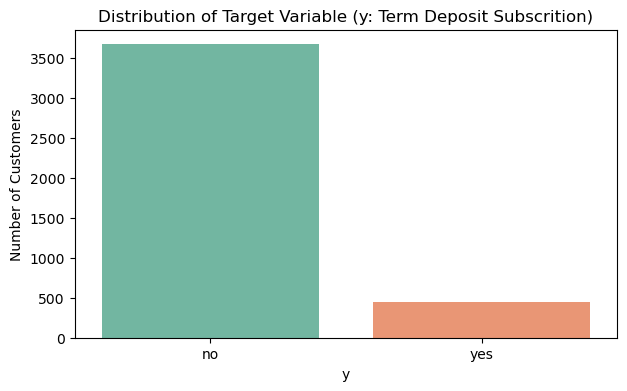

 Value Counts for Target 'y' 


y
no     89.05074
yes    10.94926
Name: proportion, dtype: float64

In [68]:
#3a)
df_bank = pd.read_csv('data/bank-additional.csv', sep= ';')
print(" 1.Basic Dataset Info ")
df_bank.info()
print("\n")
print(" 2.First 5 Rows")
display(df_bank.head())

print(" 3. Summary Statistics (Numerical Features) ")
display(df_bank.describe())

print(" 4. Missing Values Check ")
display(df_bank.isnull().sum())

plt.figure(figsize = (7, 4))
sns.countplot(x='y', data = df_bank, palette = 'Set2')
plt.title('Distribution of Target Variable (y: Term Deposit Subscrition)')
plt.ylabel('Number of Customers')
plt.show()

print(" Value Counts for Target 'y' ")
display(df_bank['y'].value_counts(normalize= True) *100)

Data Analysis
**Dataset size and layout: 4119 records with 21 columns, including categorical fields("job", "marital") and numeric fields.
**Missing data: the data is clean, there are zero missing values, so no imputation is needed.
**Target class imbalance: The target variable y (whether a client subcribed to a term deposit) is heavily skewed:
**** no: about 89%  of clients
**** yes: about 11% of clients
Because of this imbalance, plain accuracy will be misleading.

In [71]:
#3b)
from sklearn.preprocessing import StandardScaler
#Separate Features X and Target Y
X = df_bank.drop(columns = ['y', 'duration'])

y = df_bank['y'].map({'yes': 1, 'no': 0})

print (f"Original X shape: {X.shape}")

X_encoded = pd.get_dummies(X, drop_first = True)
print(f"Encoded X shape: {X_encoded.shape}")

scaler = StandardScaler()
X_preprocessed = pd.DataFrame(
    scaler.fit_transform(X_encoded),
    columns = X_encoded.columns
)
print("\n Final Preprocessed Data")
display(X_preprocessed.head())


Original X shape: (4119, 19)
Encoded X shape: (4119, 52)

 Final Preprocessed Data


,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_blue-collar,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,-0.980752,-0.209228,0.201031,-0.351356,-1.206054,-1.185448,-1.240939,-1.331707,-0.914779,1.912983,...,1.410360,-0.348463,-0.130526,-0.12563,-0.511809,-0.513697,-0.506516,-0.489050,0.411308,-0.188958
1,-0.107991,0.569634,0.201031,-0.351356,0.649441,0.715193,0.892269,0.711698,0.332862,-0.522744,...,1.410360,-0.348463,-0.130526,-0.12563,-0.511809,-0.513697,-0.506516,-0.489050,0.411308,-0.188958
2,-1.465619,-0.598660,0.201031,-0.351356,0.841389,1.528273,-0.283172,0.773427,0.836535,-0.522744,...,-0.709039,-0.348463,-0.130526,-0.12563,-0.511809,-0.513697,-0.506516,2.044782,0.411308,-0.188958
3,-0.204965,0.180203,0.201031,-0.351356,0.841389,1.528273,-0.283172,0.771697,0.836535,-0.522744,...,-0.709039,-0.348463,-0.130526,-0.12563,-0.511809,-0.513697,-0.506516,-0.489050,0.411308,-0.188958
4,0.667795,-0.598660,0.201031,-0.351356,-0.118350,-0.655478,-0.326707,0.328632,0.398028,-0.522744,...,-0.709039,2.869743,-0.130526,-0.12563,1.953854,-0.513697,-0.506516,-0.489050,0.411308,-0.188958


#3c)
In my opinion, this is a classification task, where we aim to predict whether a client will subscribe to a term deposit (yes/no)
The selected algorithms provide a well-rounded approach: Logistic Regression serves as a simple, interpretable baseline for probaility estimation; Random Forest is utilized for its robust handling of non-linear relationships and class imbalances without easily overfitting; and Gradient Boosting acts as a powerful ensemble method that maximizes predictive performance on tabular data by sequentially correcting the error of previous models.

In [79]:
#3c)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
X_train, X_test, y_train, y_test = train_test_split(
    X_preprocessed, y, test_size = 0.2, random_state = 42,stratify = y
)
print(" Training 3 basic model..")

model_lr = LogisticRegression(class_weight = 'balanced', random_state = 42)
model_rf = RandomForestClassifier(class_weight = 'balanced', random_state = 42)
model_gb = GradientBoostingClassifier(random_state=42)

model_lr.fit(X_train, y_train)
model_rf.fit(X_train, y_train)
model_gb.fit(X_train, y_train)

trained_models = {
    "Logistic Regression": model_lr,
    "Random Forest" : model_rf,
    "Gradient Boosting": model_gb
        }
print("Done training!")

 Training 3 basic model..
Done training!


In [81]:
#3d)

from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

model_rf = trained_models["Random Forest"]
y_pred = model_rf.predict(X_test)
score_split = f1_score(y_test, y_pred)
print(f"1. F1-Score using Single Train/Test Split: {score_split:.4f}")

print("\n Running 5-Fold Cross-Validation ...")
cv_scores = cross_val_score(model_rf, X_preprocessed, y, cv=5, scoring='f1')

print(f"2. F1-Scores across 5 different folds: {cv_scores}")
print(f"   => Mean CV F1-Score: {cv_scores.mean():.4f} (± {cv_scores.std():.4f})")

1. F1-Score using Single Train/Test Split: 0.3248

 Running 5-Fold Cross-Validation ...
2. F1-Scores across 5 different folds: [0.26446281 0.24590164 0.38095238 0.27642276 0.304     ]
   => Mean CV F1-Score: 0.2943 (± 0.0472)
